In [1]:
"""ML"""
import torch
import torch.nn.functional as F
import numpy as np

"""Visualization"""
from matplotlib import pyplot as plt

"""Utils"""
# Add Base directory to Python path
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Utils.paths import *
import Utils.plotting as plotting


torch.manual_seed(0)
np.random.seed(0)

%load_ext autoreload
%autoreload 2

torch.__version__, np.__version__

('2.5.1+cu118', '2.0.1')

dict_keys(['vehicle', 'person', 'bicycle', 'uav'])


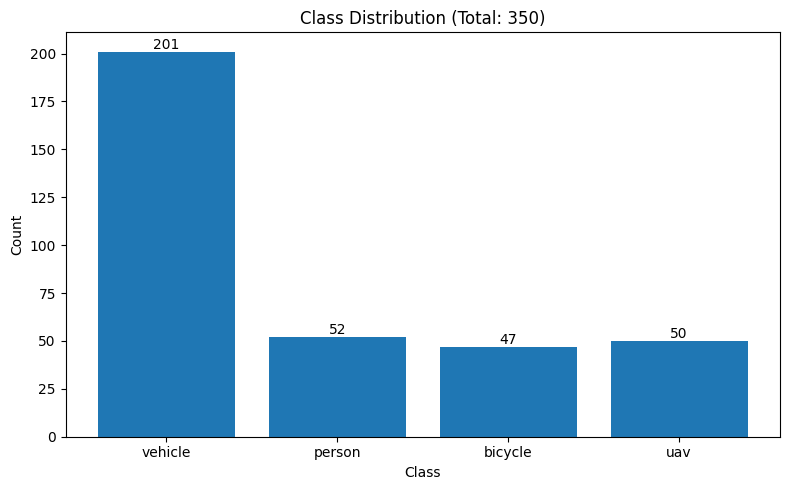

In [2]:
filename = PATHS['DATASET'] + "/moving_target_dataset.npy"
signatures = np.load(filename, allow_pickle=True)

class_names = []
class_counts = {}
signature_bin_size = []
for signature in signatures:
    if not any(signature['class_name'] in s for s in class_names):
        class_names.append(signature['class_name'])
    class_counts[signature['class_name']] = class_counts.get(signature['class_name'], 0) + 1
    signature_bin_size.append(signature['signature'].shape[0])

print(class_counts.keys())

# Extract keys and values
classes = list(class_counts.keys())
counts = list(class_counts.values())

plotting.plot_histogram_from_dict(class_counts, title=f"Class Distribution (Total: {sum(counts)})")

---
*Note*: The following cell was written by an LLM
## 1️⃣ What Each Sample Represents

Each sample in the dataset corresponds to **a single tracked object over time**, not a full radar scene.

A *signature* contains:

* `signature` → Doppler spectra for each detection in the track
* `ts` → timestamps for each detection
* `range` → physical radial distance (meters)
* `velocity` → radial velocity estimate
* `snr_db` → detection SNR
* `class_name` → object label (vehicle, person, bicycle, UAV)

Important:

> The dataset stores **tracked detections**, not raw radar range bins.

This means:

* Each row corresponds to a **detected radar return** associated with that object.
* The number of rows varies per sample.
* The `range` values are physical distances of detections — not evenly spaced bins.

---

## 2️⃣ What the Doppler Spectrum Is

The field `signature` contains **Doppler spectra**, meaning:

* FFT processing has already been applied.
* Each row is a Doppler frequency spectrum at a given time.
* The 1008 columns represent Doppler frequency bins.

So the raw shape is:

```
(N_detections, 1008)
```

Where:

* `N_detections` varies per track
* `1008` is fixed (number of Doppler bins)

Time progression occurs along the detection axis (rows).

---

## 3️⃣ Why Range Spacing Appears Irregular

Range values are not uniform because:

* The dataset contains **CFAR detections**, not full range FFT grids.
* If the object produces reflections at certain distances, only those are stored.
* No reflection → no row.

Therefore:

* Row index does NOT correspond to a fixed spatial grid.
* Index-based cropping or resizing along the row axis is physically meaningless.

---

## 4️⃣ What We Are Actually Classifying

We are performing:

> Micro-Doppler based object classification.

This means:

* We classify objects based on motion-induced Doppler patterns.
* Micro-Doppler signatures capture:

  * Walking gait (person)
  * Wheel rotation (vehicle/bicycle)
  * Rotor blades (UAV)

Classification is performed at the **track level**, not per individual detection.

---

## 5️⃣ Why We Reduce the Time Window

The dataset provides up to 1008 Doppler frames per track.

However:

* Real defense systems require **fast classification**.
* Waiting for the full track increases latency.
* Micro-Doppler features often stabilize within a shorter window.

Therefore, we reduce the time window by:

1. Computing energy per detection:

   ```
   E_i = sum(|doppler_spectrum_i|^2)
   ```
2. Finding the detection with maximum energy.
3. Extracting a fixed-length window (e.g., 256 detections) centered around it.
4. Zero-padding if necessary.

This ensures:

* The model trains on meaningful signal segments.
* Low-energy or empty detections are excluded.
* Latency is reduced.
* Input tensor size becomes fixed.

---

## 6️⃣ Final Working Representation

After preprocessing:

```
(K, 1008)
```

Where:

* `K` = fixed window size (e.g., 256)
* 1008 = Doppler bins

Optionally, this can later be projected onto a fixed range grid for spatial modeling.

---

## 7️⃣ Key Design Philosophy

We are not treating this dataset as an image.

We are treating it as:

> A time-evolving Doppler signature of a tracked object.

This is consistent with real-world radar micro-Doppler classification systems.

---

If you'd like, next I can provide a **small diagram explanation** you can also include that visually explains the axes.


In [3]:
def compute_detection_energy(signature):
    """
    signature: numpy array of shape (N, D)
    
    Returns: energy per detection (N,)
    """
    return np.sum(np.abs(signature)**2, axis=1)

In [4]:
def extract_energy_centered_window(signature, window_size=256):
    """
    Extracts a fixed-length window centered around maximum energy detection.
    
    signature: (N, D)
    window_size: number of detections to keep
    
    Returns:
        (window_size, D)
    """
    N, D = signature.shape
    
    if N == 0:
        return np.zeros((window_size, D))
    
    energy = compute_detection_energy(signature)
    peak_idx = np.argmax(energy)

    half = window_size // 2
    start = peak_idx - half
    end = peak_idx + half

    # Handle boundaries
    if start < 0:
        start = 0
        end = min(window_size, N)

    if end > N:
        end = N
        start = max(0, N - window_size)

    window = signature[start:end]

    # Pad if needed
    if window.shape[0] < window_size:
        pad_amount = window_size - window.shape[0]
        pad = np.zeros((pad_amount, D))
        window = np.vstack([window, pad])

    return window

In [5]:
def filter_low_snr(signature, snr_db, snr_threshold=3.0):
    """
    Removes detections below SNR threshold.
    
    signature: (N, D)
    snr_db: (N,)
    """
    mask = snr_db >= snr_threshold
    return signature[mask]

In [7]:
def log_normalize(window, eps=1e-8):
    """
    Apply log magnitude normalization.
    """
    magnitude = np.abs(window)
    log_mag = np.log(magnitude + eps)
    return log_mag

In [8]:
def preprocess_signature(signature_dict,
                      window_size=256,
                      snr_threshold=None):
 """
 Full preprocessing pipeline for one radar track.
 
 signature_dict: dictionary from dataset
 """
 signature = signature_dict["signature"]  # (N, 1008)
 
 # Optional SNR filtering
 if snr_threshold is not None:
     snr = signature_dict["snr_db"]
     signature = filter_low_snr(signature, snr, snr_threshold)

 # Extract fixed temporal window
 window = extract_energy_centered_window(signature,
                                         window_size=window_size)

 # Log magnitude scaling
 window = log_normalize(window)

 return window  # Shape: (window_size, 1008)

In [11]:
processed_data = []
labels = []

for sig in signatures:
    processed = preprocess_signature(sig,
                                     window_size=256,
                                     snr_threshold=3.0)
    processed_data.append(processed)
    labels.append(sig["class_name"])

processed_data = np.array(processed_data)
processed_data = processed_data[:, None, :, :] #Add channel dimension for CNN (N, 1, 256, 1008)

In [12]:
processed_data.shape, len(labels)

((350, 1, 256, 1008), 350)